# Install Packages

In [19]:
!pip install git+https://github.com/tonmoy197/cplxmodule.git
!pip install git+https://github.com/tonmoy197/auraloss.git
!pip install complexPyTorch
!pip install utils
!pip install pytorch_lightning
!pip install auraloss
!pip install pystoi
!pip install pesq
!pip install git+https://github.com/aliutkus/speechmetrics.git

  Cloning https://github.com/tonmoy197/cplxmodule.git to c:\users\zihan\appdata\local\temp\pip-req-build-i6rowds3
  Resolved https://github.com/tonmoy197/cplxmodule.git to commit 36f46863c08556348e180bbb780373aee0029ed2
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/tonmoy197/cplxmodule.git 'C:\Users\zihan\AppData\Local\Temp\pip-req-build-i6rowds3'


  Cloning https://github.com/tonmoy197/auraloss.git to c:\users\zihan\appdata\local\temp\pip-req-build-x2azf6lo
  Resolved https://github.com/tonmoy197/auraloss.git to commit f010edd6a879348cfa320799f427a718c90fc7f2
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  Running command git clone --filter=blob:none --quiet https://github.com/tonmoy197/auraloss.git 'C:\Users\zihan\AppData\Local\Temp\pip-req-build-x2azf6lo'
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [113 lines of output]
      C:\Users\zihan\AppData\Local\Temp\pip-build-env-x1cz5bz_\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:75: _MissingDynamic: `readme` defined outside of `pyproject.toml` is ignored.
      !!
      
              ********************************************************************************
              The following seems to be defined outside of `pyproject.toml`:
      
              `readme = '\n<div  align="center">\n\n# auraloss\n\n<img width="200px" src="docs/auraloss-logo.svg">\n\nA collection of audio-focused loss functions in PyTorch. \n\n[[PDF](https://www.christiansteinmetz.com/s/DMRN15__auraloss__Audio_focused_loss_functions_in_PyTorch.pdf)]\n

  Cloning https://github.com/aliutkus/speechmetrics.git to c:\users\zihan\appdata\local\temp\pip-req-build-ezodf3j_
  Resolved https://github.com/aliutkus/speechmetrics.git to commit 74619e961209b35574ea208f4827fbeab42af5e9
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Cloning https://github.com/vBaiCai/python-pesq to c:\users\zihan\appdata\local\temp\pip-install-jk4hkugx\pypesq_c03f019eaef6407ba1baeb5c6d487c57
  Resolved https://github.com/vBaiCai/python-pesq to commit 05f3a3b657bd91583dfc990230807c481433f697
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Cloning https://github.com/jfsantos/SRMRpy to c:\users\zihan\appdata\local\temp\pip-install-jk

  Running command git clone --filter=blob:none --quiet https://github.com/aliutkus/speechmetrics.git 'C:\Users\zihan\AppData\Local\Temp\pip-req-build-ezodf3j_'
  Running command git clone --filter=blob:none --quiet https://github.com/vBaiCai/python-pesq 'C:\Users\zihan\AppData\Local\Temp\pip-install-jk4hkugx\pypesq_c03f019eaef6407ba1baeb5c6d487c57'
  Running command git clone --filter=blob:none --quiet https://github.com/jfsantos/SRMRpy 'C:\Users\zihan\AppData\Local\Temp\pip-install-jk4hkugx\srmrpy_33866460cd264e4a8dedf40e172587cb'
  Running command git clone --filter=blob:none --quiet https://github.com/ludlows/python-pesq 'C:\Users\zihan\AppData\Local\Temp\pip-install-jk4hkugx\pesq_4a29ba154b194594b1369427e1d80126'


# Load Dataset 

In [2]:
# import os
import numpy as np
import soundfile as sf
from glob import glob
from librosa import stft
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.image as mpimg
from pathlib import Path
import warnings
from tqdm import tqdm
import math

# Get the directory where the script is located
# script_dir = Path(__file__).parent.resolve()

warnings.filterwarnings("ignore")
epsilon = np.finfo(np.float32).eps
# parcentage_of_audio = 0.45

class LoadDataset(Dataset):
    def __init__(self, data_dir):
        self.audio_files = sorted(glob(f"{data_dir}/*.wav"))
        # number_of_audio = math.floor(len(self.audio_files) * parcentage_of_audio)
        # self.audio_files = self.audio_files[:number_of_audio]
        # self.audio_files = self.audio_files[:10]
        # print(len(self.audio_files))

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, idx):
        # print(self.audio_files[idx])
        audio = sf.read(self.audio_files[idx])[0]
        noisy, clean = audio[:, 0].transpose(), audio[:, 1]
        noisy, clean = torch.FloatTensor(noisy).squeeze(), torch.FloatTensor(clean).squeeze()
        batch = {'noisy': noisy, 'clean': clean}
        return batch

def norm(x):
    return x / (np.max(np.abs(x)) + 1e-10)

def lps(audio):
    spec = norm(stft(audio, n_fft=512, hop_length=128, win_length=512, window=np.sqrt(np.hanning(512))))
    spec = db(spec)
    return spec

def db(x):
    xdb = 20 * np.log10(np.abs(x) + np.spacing(1))
    xdb[xdb < -120] = -120
    xdb = (xdb + 60) / 60
    return xdb




# Utils

In [3]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import numpy as np
import functools
import os, numbers, math, signal
from typing import Union, List, Sequence
from distutils.version import LooseVersion
import warnings
import torch as th

warnings.filterwarnings("ignore")
EPS = torch.as_tensor(torch.finfo(torch.get_default_dtype()).eps)


class ComplexTensor:
    def __init__(self, real: Union[torch.Tensor, np.ndarray], imag=None):
        if imag is None:
            if isinstance(real, np.ndarray):
                if real.dtype.kind == 'c':
                    imag = real.imag
                    real = real.real
                else:
                    imag = np.zeros_like(real)
            else:
                imag = torch.zeros_like(real)

        if isinstance(real, np.ndarray):
            real = torch.from_numpy(real)
        if isinstance(imag, np.ndarray):
            imag = torch.from_numpy(imag)

        if not torch.is_tensor(real):
            raise TypeError(
                f'The first arg must be torch.Tensor'
                f'but got {type(real)}')

        if not torch.is_tensor(imag):
            raise TypeError(
                f'The second arg must be torch.Tensor'
                f'but got {type(imag)}')
        if not real.size() == imag.size():
            raise ValueError(f'The two inputs must have same sizes: '
                             f'{real.size()} != {imag.size()}')

        self.real = real
        self.imag = imag

    def __getitem__(self, item) -> 'ComplexTensor':
        return ComplexTensor(self.real[item], self.imag[item])

    def __setitem__(self, item, value: Union['ComplexTensor',
                                             torch.Tensor, numbers.Number]):
        if isinstance(value, (ComplexTensor, complex)):
            self.real[item] = value.real
            self.imag[item] = value.imag
        else:
            self.real[item] = value
            self.imag[item] = 0

    def __mul__(self,
                other: Union['ComplexTensor', torch.Tensor, numbers.Number]) \
            -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, complex)):
            return ComplexTensor(
                self.real * other.real - self.imag * other.imag,
                self.real * other.imag + self.imag * other.real)
        else:
            return ComplexTensor(self.real * other, self.imag * other)

    def __rmul__(self,
                 other: Union['ComplexTensor', torch.Tensor, numbers.Number]) \
            -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, complex)):
            return ComplexTensor(
                other.real * self.real - other.imag * self.imag,
                other.imag * self.real + other.real * self.imag)
        else:
            return ComplexTensor(other * self.real, other * self.imag)

    def __imul__(self, other):
        if isinstance(other, (ComplexTensor, numbers.Complex)):
            t = self * other
            self.real = t.real
            self.imag = t.imag
        else:
            self.real *= other
            self.imag *= other
        return self

    def __truediv__(self, other) -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, complex)):
            den = other.real ** 2 + other.imag ** 2
            return ComplexTensor(
                (self.real * other.real + self.imag * other.imag) / den,
                (-self.real * other.imag + self.imag * other.real) / den)
        else:
            return ComplexTensor(self.real / other, self.imag / other)

    def __rtruediv__(self, other) -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, complex)):
            den = self.real ** 2 + self.imag ** 2
            return ComplexTensor(
                (other.real * self.real + other.imag * self.imag) / den,
                (-other.real * self.imag + other.imag * self.real) / den)
        else:
            den = self.real ** 2 + self.imag ** 2
            return ComplexTensor(other * self.real / den,
                                 -other * self.imag / den)

    def __itruediv__(self, other) -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, numbers.Complex)):
            t = self / other
            self.real = t.real
            self.imag = t.imag
        else:
            self.real /= other
            self.imag /= other
        return self

    def __add__(self, other) -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, complex)):
            return ComplexTensor(self.real + other.real,
                                 self.imag + other.imag)
        else:
            return ComplexTensor(self.real + other, self.imag)

    def __radd__(self, other) -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, complex)):
            return ComplexTensor(other.real + self.real,
                                 other.imag + self.imag)
        else:
            return ComplexTensor(other + self.real, self.imag)

    def __iadd__(self, other) -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, complex)):
            self.real += other.real
            self.imag += other.imag
        else:
            self.real += other
        return self

    def __sub__(self, other) -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, complex)):
            return ComplexTensor(self.real - other.real,
                                 self.imag - other.imag)
        else:
            return ComplexTensor(self.real - other, self.imag)

    def __rsub__(self, other) -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, complex)):
            return ComplexTensor(other.real - self.real,
                                 other.imag - self.imag)
        else:
            return ComplexTensor(other - self.real, self.imag)

    def __isub__(self, other) -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, complex)):
            self.real -= other.real
            self.imag -= other.imag
        else:
            self.real -= other
        return self

    def __matmul__(self, other) -> 'ComplexTensor':
        if isinstance(other, ComplexTensor):
            o_real = torch.matmul(self.real, other.real) - \
                     torch.matmul(self.imag, other.imag)
            o_imag = torch.matmul(self.real, other.imag) + \
                     torch.matmul(self.imag, other.real)
        else:
            o_real = torch.matmul(self.real, other)
            o_imag = torch.matmul(self.imag, other)
        return ComplexTensor(o_real, o_imag)

    def __rmatmul__(self, other) -> 'ComplexTensor':
        if isinstance(other, ComplexTensor):
            o_real = torch.matmul(other.real, self.real) - \
                     torch.matmul(other.imag, self.imag)
            o_imag = torch.matmul(other.real, self.imag) + \
                     torch.matmul(other.imag, self.real)
        else:
            o_real = torch.matmul(other, self.real)
            o_imag = torch.matmul(other, self.imag)
        return ComplexTensor(o_real, o_imag)

    def __imatmul__(self, other) -> 'ComplexTensor':
        if isinstance(other, (ComplexTensor, numbers.Complex)):
            t = self @ other
            self.real = t.real
            self.imag = t.imag
        else:
            self.real @= other
            self.imag @= other
        return self

    def __neg__(self) -> 'ComplexTensor':
        return ComplexTensor(-self.real, -self.imag)

    def __eq__(self, other) -> torch.Tensor:
        if isinstance(other, (ComplexTensor, complex)):
            return (self.real == other.real) ** (self.imag == other.imag)
        else:
            return (self.real == other) ** (self.imag == 0)

    def __len__(self) -> int:
        return len(self.real)

    def __repr__(self) -> str:
        return 'ComplexTensor(\nReal:\n' \
               + repr(self.real) + '\nImag:\n' + repr(self.imag) + '\n)'

    def __abs__(self) -> torch.Tensor:
        return (self.real * self.real + self.imag * self.imag).sqrt()

    def __pow__(self, exponent) -> 'ComplexTensor':
        if exponent == -2:
            return 1 / (self * self)
        if exponent == -1:
            return 1 / self
        if exponent == 0:
            return ComplexTensor(torch.ones_like(self.real))
        if exponent == 1:
            return self.clone()
        if exponent == 2:
            return self * self

        _abs = self.abs().pow(exponent)
        _angle = exponent * self.angle()
        return ComplexTensor(_abs * torch.cos(_angle),
                             _abs * torch.sin(_angle))

    def __ipow__(self, exponent) -> 'ComplexTensor':
        c = self ** exponent
        self.real = c.real
        self.imag = c.imag
        return self

    def abs(self) -> torch.Tensor:
        return (self.real * self.real + self.imag * self.imag).sqrt()

    def angle(self) -> torch.Tensor:
        return torch.atan2(self.imag, self.real)

    def backward(self) -> None:
        self.real.backward()
        self.imag.backward()

    def byte(self) -> 'ComplexTensor':
        return ComplexTensor(self.real.byte(), self.imag.byte())

    def clone(self) -> 'ComplexTensor':
        return ComplexTensor(self.real.clone(), self.imag.clone())

    def flatten(self, dim) -> 'ComplexTensor':
        return ComplexTensor(torch.flatten(self.real, dim), torch.flatten(self.imag, dim))

    def reshape(self, *shape) -> 'ComplexTensor':
        return ComplexTensor(self.real.reshape(shape), self.imag.reshape(shape))

    def zeromean(self, dim) -> 'ComplexTensor':
        self.real = self.real - torch.mean(self.real, dim=dim, keepdim=True)
        self.imag = self.imag - torch.mean(self.imag, dim=dim, keepdim=True)
        return ComplexTensor(self.real, self.imag)

    def conj(self) -> 'ComplexTensor':
        return ComplexTensor(self.real, -self.imag)

    def conj_(self) -> 'ComplexTensor':
        self.imag.neg_()
        return self

    def contiguous(self) -> 'ComplexTensor':
        return ComplexTensor(self.real.contiguous(), self.imag.contiguous())

    def copy_(self) -> 'ComplexTensor':
        self.real = self.real.copy_()
        self.imag = self.imag.copy_()
        return self

    def cpu(self) -> 'ComplexTensor':
        return ComplexTensor(self.real.cpu(), self.imag.cpu())

    def cuda(self) -> 'ComplexTensor':
        return ComplexTensor(self.real.cuda(), self.imag.cuda())

    def expand(self, *sizes):
        return ComplexTensor(self.real.expand(*sizes),
                             self.imag.expand(*sizes))

    def expand_as(self, *args, **kwargs):
        return ComplexTensor(self.real.expand_as(*args, **kwargs),
                             self.imag.expand_as(*args, **kwargs))

    def detach(self) -> 'ComplexTensor':
        return ComplexTensor(self.real.detach(), self.imag.detach())

    def detach_(self) -> 'ComplexTensor':
        self.real.detach_()
        self.imag.detach_()
        return self

    @property
    def device(self):
        assert self.real.device == self.imag.device
        return self.real.device

    def diag(self) -> 'ComplexTensor':
        return ComplexTensor(self.real.diag(), self.imag.diag())

    def diagonal(self) -> 'ComplexTensor':
        return ComplexTensor(self.real.diag(), self.imag.diag())

    def dim(self) -> int:
        return self.real.dim()

    def double(self) -> 'ComplexTensor':
        return ComplexTensor(self.real.double(), self.imag.double())

    @property
    def dtype(self) -> torch.dtype:
        return self.real.dtype

    def eq(self, other) -> torch.Tensor:
        if isinstance(other, (ComplexTensor, complex)):
            return (self.real == other.real) * (self.imag == other.imag)
        else:
            return (self.real == other) * (self.imag == 0)

    def equal(self, other) -> bool:
        if isinstance(other, (ComplexTensor, complex)):
            return self.real.equal(other.real) and self.imag.equal(other.imag)
        else:
            return self.real.equal(other) and self.imag.equal(0)

    def float(self) -> 'ComplexTensor':
        return ComplexTensor(self.real.float(), self.imag.float())

    def fill(self, value) -> 'ComplexTensor':
        if isinstance(value, complex):
            return ComplexTensor(self.real.fill(value.real),
                                 self.imag.fill(value.imag))
        else:
            return ComplexTensor(self.real.fill(value), self.imag.fill(0))

    def fill_(self, value) -> 'ComplexTensor':
        if isinstance(value, complex):
            self.real.fill_(value.real)
            self.imag.fill_(value.imag)
        else:
            self.real.fill_(value)
            self.imag.fill_(0)
        return self

    def gather(self, dim, index) -> 'ComplexTensor':
        return ComplexTensor(self.real.gather(dim, index),
                             self.real.gather(dim, index))

    def get_device(self, *args, **kwargs):
        return self.real.get_device(*args, **kwargs)

    def half(self) -> 'ComplexTensor':
        return ComplexTensor(self.real.half(), self.imag.half())

    def index_add(self, dim, index, tensor) -> 'ComplexTensor':
        return ComplexTensor(self.real.index_add(dim, index, tensor),
                             self.imag.index_add(dim, index, tensor))

    def index_copy(self, dim, index, tensor) -> 'ComplexTensor':
        return ComplexTensor(self.real.index_copy(dim, index, tensor),
                             self.imag.index_copy(dim, index, tensor))

    def index_fill(self, dim, index, value) -> 'ComplexTensor':
        return ComplexTensor(self.real.index_fill(dim, index, value),
                             self.imag.index_fill(dim, index, value))

    def index_select(self, dim, index) -> 'ComplexTensor':
        return ComplexTensor(self.real.index_select(dim, index),
                             self.imag.index_select(dim, index))

    def inverse(self, ntry=5):
        # m x n x n
        in_size = self.size()
        a = self.view(-1, self.size(-1), self.size(-1))
        # see "The Matrix Cookbook" (http://www2.imm.dtu.dk/pubdb/p.php?3274)
        # "Section 4.3"
        for i in range(ntry):
            t = i * 0.1

            e = a.real + t * a.imag
            f = a.imag - t * a.real

            try:
                x = torch.matmul(f, e.inverse())
                z = (e + torch.matmul(x, f)).inverse()
            except Exception:
                if i == ntry - 1:
                    raise
                continue

            if t != 0.:
                eye = torch.eye(a.real.size(-1), dtype=a.real.dtype,
                                device=a.real.device)[None]
                o_real = torch.matmul(z, (eye - t * x))
                o_imag = -torch.matmul(z, (t * eye + x))
            else:
                o_real = z
                o_imag = -torch.matmul(z, x)

            o = ComplexTensor(o_real, o_imag)
            return o.view(*in_size)

    def item(self) -> numbers.Number:
        return self.real.item() + 1j * self.imag.item()

    def masked_fill(self, mask, value) -> 'ComplexTensor':
        if isinstance(value, complex):
            return ComplexTensor(self.real.masked_fill(mask, value.real),
                                 self.imag.masked_fill(mask, value.imag))

        else:
            return ComplexTensor(self.real.masked_fill(mask, value),
                                 self.imag.masked_fill(mask, 0))

    def masked_fill_(self, mask, value) -> 'ComplexTensor':
        if isinstance(value, complex):
            self.real.masked_fill_(mask, value.real)
            self.imag.masked_fill_(mask, value.imag)
        else:
            self.real.masked_fill_(mask, value)
            self.imag.masked_fill_(mask, 0)
        return self

    def mean(self, *args, **kwargs) -> 'ComplexTensor':
        return ComplexTensor(self.real.mean(*args, **kwargs),
                             self.imag.mean(*args, **kwargs))

    def neg(self) -> 'ComplexTensor':
        return ComplexTensor(-self.real, -self.imag)

    def neg_(self) -> 'ComplexTensor':
        self.real.neg_()
        self.imag.neg_()
        return self

    def nelement(self) -> int:
        return self.real.nelement()

    def numel(self) -> int:
        return self.real.numel()

    def new(self, *args, **kwargs) -> 'ComplexTensor':
        return ComplexTensor(self.real.new(*args, **kwargs),
                             self.imag.new(*args, **kwargs))

    def new_empty(self, size, dtype=None, device=None, requires_grad=False) \
            -> 'ComplexTensor':
        real = self.real.new_empty(size,
                                   dtype=dtype,
                                   device=device,
                                   requires_grad=requires_grad)
        imag = self.imag.new_empty(size,
                                   dtype=dtype,
                                   device=device,
                                   requires_grad=requires_grad)
        return ComplexTensor(real, imag)

    def new_full(self, size, fill_value, dtype=None, device=None,
                 requires_grad=False) -> 'ComplexTensor':
        if isinstance(fill_value, complex):
            real_value = fill_value.real
            imag_value = fill_value.imag
        else:
            real_value = fill_value
            imag_value = 0.

        real = self.real.new_full(size,
                                  fill_value=real_value,
                                  dtype=dtype,
                                  device=device,
                                  requires_grad=requires_grad)
        imag = self.imag.new_full(size,
                                  fill_value=imag_value,
                                  dtype=dtype,
                                  device=device,
                                  requires_grad=requires_grad)
        return ComplexTensor(real, imag)

    def new_tensor(self, data, dtype=None, device=None,
                   requires_grad=False) -> 'ComplexTensor':
        if isinstance(data, ComplexTensor):
            real = data.real
            imag = data.imag
        elif isinstance(data, np.ndarray):
            if data.dtype.kind == 'c':
                real = data.real
                imag = data.imag
            else:
                real = data
                imag = None
        else:
            real = data
            imag = None

        real = self.real.new_tensor(real,
                                    dtype=dtype,
                                    device=device,
                                    requires_grad=requires_grad)
        if imag is None:
            imag = torch.zeros_like(real,
                                    dtype=dtype,
                                    device=device,
                                    requires_grad=requires_grad)
        else:
            imag = self.imag.new_tensor(imag,
                                        dtype=dtype,
                                        device=device,
                                        requires_grad=requires_grad)
        return ComplexTensor(real, imag)

    def numpy(self) -> np.ndarray:
        return self.real.numpy() + 1j * self.imag.numpy()

    def permute(self, *dims) -> 'ComplexTensor':
        return ComplexTensor(self.real.permute(*dims),
                             self.imag.permute(*dims))

    def pow(self, exponent) -> 'ComplexTensor':
        return self ** exponent

    def requires_grad_(self) -> 'ComplexTensor':
        self.real.requires_grad_()
        self.imag.requires_grad_()
        return self

    @property
    def requires_grad(self):
        assert self.real.requires_grad == self.imag.requires_grad
        return self.real.requires_grad

    @requires_grad.setter
    def requires_grad(self, value):
        self.real.requires_grad = value
        self.imag.requires_grad = value

    def repeat(self, *sizes):
        return ComplexTensor(self.real.repeat(*sizes),
                             self.imag.repeat(*sizes))

    def retain_grad(self) -> 'ComplexTensor':
        self.real.retain_grad()
        self.imag.retain_grad()
        return self

    def share_memory_(self) -> 'ComplexTensor':
        self.real.share_memory_()
        self.imag.share_memory_()
        return self

    @property
    def shape(self) -> torch.Size:
        return self.real.shape

    def size(self, *args, **kwargs) -> torch.Size:
        return self.real.size(*args, **kwargs)

    def sqrt(self) -> 'ComplexTensor':
        return self ** 0.5

    def squeeze(self, dim) -> 'ComplexTensor':
        return ComplexTensor(self.real.squeeze(dim),
                             self.imag.squeeze(dim))

    def sum(self, *args, **kwargs) -> 'ComplexTensor':
        return ComplexTensor(self.real.sum(*args, **kwargs),
                             self.imag.sum(*args, **kwargs), )

    def take(self, indices) -> 'ComplexTensor':
        return ComplexTensor(self.real.take(indices), self.imag.take(indices))

    def to(self, *args, **kwargs) -> 'ComplexTensor':
        return ComplexTensor(self.real.to(*args, **kwargs),
                             self.imag.to(*args, **kwargs))

    def tolist(self) -> List[numbers.Number]:
        return [r + 1j * i
                for r, i in zip(self.real.tolist(), self.imag.tolist())]

    def transpose(self, dim0, dim1) -> 'ComplexTensor':
        return ComplexTensor(self.real.transpose(dim0, dim1),
                             self.imag.transpose(dim0, dim1))

    def transpose_(self, dim0, dim1) -> 'ComplexTensor':
        self.real.transpose_(dim0, dim1)
        self.imag.transpose_(dim0, dim1)
        return self

    def type(self) -> str:
        return self.real.type()

    def unfold(self, dim, size, step):
        return ComplexTensor(self.real.unfold(dim, size, step),
                             self.imag.unfold(dim, size, step))

    def unsqueeze(self, dim) -> 'ComplexTensor':
        return ComplexTensor(self.real.unsqueeze(dim),
                             self.imag.unsqueeze(dim))

    def unsqueeze_(self, dim) -> 'ComplexTensor':
        self.real.unsqueeze_(dim)
        self.imag.unsqueeze_(dim)
        return self

    def view(self, *args, **kwargs) -> 'ComplexTensor':
        return ComplexTensor(self.real.view(*args, **kwargs),
                             self.imag.view(*args, **kwargs))

    def view_as(self, tensor):
        return self.view(tensor.size())


def init_kernel(frame_len, frame_hop, num_fft=None, window="sqrt_hann"):
    if window != "sqrt_hann":
        raise RuntimeError("Now only support sqrt hanning window in order "
                           "to make signal perfectly reconstructed")
    fft_size = 2 ** math.ceil(math.log2(frame_len)) if not num_fft else num_fft
    window = torch.hann_window(frame_len) ** 0.5
    S_ = 0.5 * (fft_size * fft_size / frame_hop) ** 0.5
    w = torch.fft.rfft(torch.eye(fft_size) / S_)
    kernel = torch.stack([w.real, w.imag], -1)
    kernel = torch.transpose(kernel, 0, 2) * window
    kernel = torch.reshape(kernel, (fft_size + 2, 1, frame_len))
    return kernel


class STFTBase(nn.Module):
    def __init__(self, frame_len, frame_hop, window="sqrt_hann", num_fft=None):
        super(STFTBase, self).__init__()
        K = init_kernel(frame_len, frame_hop, num_fft=num_fft, window=window)
        self.K = nn.Parameter(K, requires_grad=False)
        self.stride = frame_hop
        self.window = window

    def freeze(self): self.K.requires_grad = False

    def unfreeze(self): self.K.requires_grad = True

    def check_nan(self):
        num_nan = torch.sum(torch.isnan(self.K))
        if num_nan:
            raise RuntimeError(
                "detect nan in STFT kernels: {:d}".format(num_nan))

    def extra_repr(self):
        return "window={0}, stride={1}, requires_grad={2}, kernel_size={3[0]}x{3[2]}".format(self.window, self.stride,
                                                                                             self.K.requires_grad,
                                                                                             self.K.shape)


class STFT(STFTBase):
    def __init__(self, *args, **kwargs):
        super(STFT, self).__init__(*args, **kwargs)

    def forward(self, x):
        if x.dim() not in [2, 3]:
            print(x.shape)
            raise RuntimeError("Expect 2D/3D tensor, but got {:d}D".format(
                x.dim()))
        self.check_nan()
        if x.dim() == 2:
            x = torch.unsqueeze(x, 1)

        # if self.K.device != x.device:
        #     self.K = self.K.to(x.device)

        c = F.conv1d(x, self.K, stride=self.stride, padding=0)
        r, i = torch.chunk(c, 2, dim=1)
        m = (r ** 2 + i ** 2) ** 0.5
        p = torch.atan2(i, r)
        return m, p, r, i


class iSTFT(STFTBase):
    def __init__(self, *args, **kwargs):
        super(iSTFT, self).__init__(*args, **kwargs)

    def forward(self, m, p, squeeze=False):
        if p.dim() != m.dim() or p.dim() not in [2, 3]:
            raise RuntimeError("Expect 2D/3D tensor, but got {:d}D".format(
                p.dim()))
        self.check_nan()
        if p.dim() == 2:
            p = torch.unsqueeze(p, 0)
            m = torch.unsqueeze(m, 0)
        r = m * torch.cos(p)
        i = m * torch.sin(p)
        c = torch.cat([r, i], dim=1)
        s = F.conv_transpose1d(c, self.K, stride=self.stride, padding=0)
        if squeeze:
            s = torch.squeeze(s)
        return s


class Conv1D(nn.Conv1d):
    def __init__(self, *args, **kwargs):
        super(Conv1D, self).__init__(*args, **kwargs)

    def forward(self, x, squeeze=False):
        if x.dim() not in [2, 3]:
            raise RuntimeError("{} accept 2/3D tensor as input".format(
                self.__name__))
        x = super().forward(x if x.dim() == 3 else th.unsqueeze(x, 1))
        if squeeze:
            x = th.squeeze(x)
        return x


class Identity(nn.Module):
    def __init__(self):
        super(Identity, self).__init__()
        self._name = 'Identity'

    def forward(self, x): return x


class SelectItem(nn.Module):
    def __init__(self, item_index):
        super(SelectItem, self).__init__()
        self._name = 'selectitem'
        self.item_index = item_index

    def forward(self, inputs):
        return inputs[self.item_index]


class ChannelWiseLayerNorm(nn.LayerNorm):
    def __init__(self, *args, **kwargs):
        super(ChannelWiseLayerNorm, self).__init__(*args, **kwargs)

    def forward(self, x):
        if x.dim() != 3:
            raise RuntimeError("{} accept 3D tensor as input".format(
                self.__name__))
        x = torch.transpose(x, 1, 2)
        x = super(ChannelWiseLayerNorm, self).forward(x)
        x = torch.transpose(x, 1, 2)
        return x


class GlobalLayerNorm(nn.Module):
    """Global Layer Normalization (gLN)"""

    def __init__(self, channel_size):
        super(GlobalLayerNorm, self).__init__()
        self.gamma = nn.Parameter(torch.Tensor(1, channel_size, 1))  # [1, N, 1]
        self.beta = nn.Parameter(torch.Tensor(1, channel_size, 1))  # [1, N, 1]
        self.reset_parameters()

    def reset_parameters(self):
        self.gamma.data.fill_(1)
        self.beta.data.zero_()

    def forward(self, y):
        """
        Args:
            y: [M, N, K], M is batch size, N is channel size, K is length
        Returns:
            gLN_y: [M, N, K]
        """
        # TODO: in torch 1.0, torch.mean() support dim list
        mean = y.mean(dim=1, keepdim=True).mean(dim=2, keepdim=True)  # [M, 1, 1]
        var = (torch.pow(y - mean, 2)).mean(dim=1, keepdim=True).mean(dim=2, keepdim=True)
        gLN_y = self.gamma * (y - mean) / torch.pow(var + EPS, 0.5) + self.beta
        return gLN_y


def _fcomplex(func, nthargs=0):
    @functools.wraps(func)
    def wrapper(*args, **kwargs) -> Union[ComplexTensor, torch.Tensor]:
        signal = args[nthargs]
        if isinstance(signal, ComplexTensor):
            real_args = args[:nthargs] + (signal.real,) + args[nthargs + 1:]
            imag_args = args[:nthargs] + (signal.imag,) + args[nthargs + 1:]
            real = func(*real_args, **kwargs)
            imag = func(*imag_args, **kwargs)
            return ComplexTensor(real, imag)
        else:
            return func(*args, **kwargs)

    return wrapper


def einsum(equation, operands):
    """Einsum

    >>> import numpy
    >>> def get(*shape):
    ...     real = np.random.rand(*shape)
    ...     imag = np.random.rand(*shape)
    ...     return real + 1j * imag
    >>> x = get(3, 4, 5)
    >>> y = get(3, 5, 6)
    >>> z = get(3, 6, 7)
    >>> test = einsum('aij,ajk,akl->ail',
    ...               [ComplexTensor(x), ComplexTensor(y), ComplexTensor(z)])
    >>> valid = np.einsum('aij,ajk,akl->ail', x, y, z)
    >>> np.testing.assert_allclose(test.numpy(), valid)

    """
    x = operands[0]
    if isinstance(x, ComplexTensor):
        real_operands = [[x.real]]
        imag_operands = [[x.imag]]
    else:
        real_operands = [[x]]
        imag_operands = []

    for x in operands[1:]:
        if isinstance(x, ComplexTensor):
            real_operands, imag_operands = \
                [ops + [x.real] for ops in real_operands] + \
                [ops + [-x.imag] for ops in imag_operands], \
                [ops + [x.imag] for ops in real_operands] + \
                [ops + [x.real] for ops in imag_operands]
        else:
            real_operands = [ops + [x] for ops in real_operands]
            imag_operands = [ops + [x] for ops in imag_operands]

    real = sum([torch.einsum(equation, ops) for ops in real_operands])
    imag = sum([torch.einsum(equation, ops) for ops in imag_operands])
    return ComplexTensor(real, imag)


def cat(seq: Sequence[Union[ComplexTensor, torch.Tensor]], dim=0, out=None):
    reals = [v.real if isinstance(v, ComplexTensor) else v for v in seq]
    imags = [v.imag if isinstance(v, ComplexTensor)
             else torch.zeros_like(v.real) for v in seq]
    if out is not None:
        out_real = out.real
        out_imag = out.imag
    else:
        out_real = out_imag = None
    return ComplexTensor(torch.cat(reals, dim, out=out_real),
                         torch.cat(imags, dim, out=out_imag))


def stack(seq: Sequence[Union[ComplexTensor, torch.Tensor]], dim=0, out=None):
    reals = [v.real if isinstance(v, ComplexTensor) else v for v in seq]
    imags = [v.imag if isinstance(v, ComplexTensor)
             else torch.zeros_like(v.real) for v in seq]
    if out is not None:
        out_real = out.real
        out_imag = out.imag
    else:
        out_real = out_imag = None
    return ComplexTensor(torch.stack(reals, dim, out=out_real),
                         torch.stack(imags, dim, out=out_imag))


pad = _fcomplex(F.pad)


@_fcomplex
def reverse(tensor: torch.Tensor, dim=0) -> torch.Tensor:
    # https://discuss.pytorch.org/t/how-to-reverse-a-torch-tensor/382
    idx = [i for i in range(tensor.size(dim) - 1, -1, -1)]
    idx = torch.LongTensor(idx).to(tensor.device)
    inverted_tensor = tensor.index_select(dim, idx)
    return inverted_tensor


@_fcomplex
def signal_frame(signal: torch.Tensor,
                 frame_length: int, frame_step: int,
                 pad_value=0) -> torch.Tensor:
    """Expands signal into frames of frame_length.

    Args:
        signal : (B * F, D, T)
    Returns:
        torch.Tensor: (B * F, D, T, W)
    """
    signal = F.pad(signal, (0, frame_length - 1), 'constant', pad_value)
    indices = sum([list(range(i, i + frame_length))
                   for i in range(0, signal.size(-1) - frame_length + 1,
                                  frame_step)], [])

    signal = signal[..., indices].view(*signal.size()[:-1], -1, frame_length)
    return signal


def trace(a: ComplexTensor) -> ComplexTensor:
    if LooseVersion(torch.__version__) >= LooseVersion('1.3'):
        datatype = torch.bool
    else:
        datatype = torch.uint8
    E = torch.eye(a.real.size(-1), dtype=datatype).expand(*a.size())
    if LooseVersion(torch.__version__) >= LooseVersion('1.1'):
        E = E.type(torch.bool)
    return a[E].view(*a.size()[:-1]).sum(-1)


def allclose(a: Union[ComplexTensor, torch.Tensor],
             b: Union[ComplexTensor, torch.Tensor],
             rtol=1e-05, atol=1e-08, equal_nan=False) -> bool:
    if isinstance(a, ComplexTensor) and isinstance(b, ComplexTensor):
        return torch.allclose(a.real, b.real,
                              rtol=rtol, atol=atol, equal_nan=equal_nan) and \
               torch.allclose(a.imag, b.imag,
                              rtol=rtol, atol=atol, equal_nan=equal_nan)
    elif not isinstance(a, ComplexTensor) and isinstance(b, ComplexTensor):
        return torch.allclose(a.real, b.real,
                              rtol=rtol, atol=atol, equal_nan=equal_nan) and \
               torch.allclose(torch.zeros_like(b.imag), b.imag,
                              rtol=rtol, atol=atol, equal_nan=equal_nan)
    elif isinstance(a, ComplexTensor) and not isinstance(b, ComplexTensor):
        return torch.allclose(a.real, b,
                              rtol=rtol, atol=atol, equal_nan=equal_nan) and \
               torch.allclose(a.imag, torch.zeros_like(a.imag),
                              rtol=rtol, atol=atol, equal_nan=equal_nan)
    else:
        return torch.allclose(a, b, rtol=rtol, atol=atol, equal_nan=equal_nan)


def matmul(a: Union[ComplexTensor, torch.Tensor],
           b: Union[ComplexTensor, torch.Tensor]) -> ComplexTensor:
    if isinstance(a, ComplexTensor) and isinstance(b, ComplexTensor):
        return a @ b
    elif not isinstance(a, ComplexTensor) and isinstance(b, ComplexTensor):
        o_imag = torch.matmul(a, b.imag)
    elif isinstance(a, ComplexTensor) and not isinstance(b, ComplexTensor):
        return a @ b
    else:
        o_real = torch.matmul(a.real, b.real)
        o_imag = torch.zeros_like(o_real)
    return ComplexTensor(o_real, o_imag)


def complex_matrix2real_matrix(c: ComplexTensor) -> torch.Tensor:
    # NOTE(kamo):
    # Complex value can be expressed as follows
    #   a + bi => a * x + b y
    # where
    #   x = |1 0|  y = |0 -1|
    #       |0 1|,     |1  0|
    # A complex matrix can be also expressed as
    #   |A -B|
    #   |B  A|
    # and complex vector can be expressed as
    #   |A|
    #   |B|

    assert c.size(-2) == c.size(-1), c.size()
    # (∗, m, m) -> (*, 2m, 2m)
    return torch.cat(
        [torch.cat([c.real, -c.imag], dim=-1), torch.cat([c.imag, c.real], dim=-1)],
        dim=-2,
    )


def complex_vector2real_vector(c: ComplexTensor) -> torch.Tensor:
    # (∗, m, k) -> (*, 2m, k)
    return torch.cat([c.real, c.imag], dim=-2)


def real_matrix2complex_matrix(c: torch.Tensor) -> ComplexTensor:
    assert c.size(-2) == c.size(-1), c.size()
    # (∗, 2m, 2m) -> (*, m, m)
    n = c.size(-1)
    assert n % 2 == 0, n
    real = c[..., : n // 2, : n // 2]
    imag = c[..., n // 2:, : n // 2]
    return ComplexTensor(real, imag)


def real_vector2complex_vector(c: torch.Tensor) -> ComplexTensor:
    # (∗, 2m, k) -> (*, m, k)
    n = c.size(-2)
    assert n % 2 == 0, n
    real = c[..., : n // 2, :]
    imag = c[..., n // 2:, :]
    return ComplexTensor(real, imag)


def solve(b: ComplexTensor, a: ComplexTensor) -> ComplexTensor:
    """Solve ax = b"""
    a = complex_matrix2real_matrix(a)
    b = complex_vector2real_vector(b)
    x, LU = torch.solve(b, a)

    return real_vector2complex_vector(x), real_matrix2complex_matrix(LU)



### Modules 

In [4]:
# Modules
import torch
import copy
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from cplxmodule.nn import CplxConv2d, CplxConvTranspose2d, CplxBatchNorm2d, CplxLinear, CplxConv1d, CplxBatchNorm1d
from complexPyTorch.complexFunctions import complex_relu
from torch.nn.modules.module import Module
from torch.nn.modules.container import ModuleList
from torch.nn.init import xavier_uniform_
from torch.nn.modules.dropout import Dropout
from torch.nn.modules.linear import Linear
from torch.nn.modules.rnn import LSTM, GRU
from torch.nn.modules.normalization import LayerNorm
import warnings

warnings.filterwarnings("ignore")
torch.manual_seed(9999)
EPS = torch.as_tensor(torch.finfo(torch.get_default_dtype()).eps)


def param(nnet, Mb=True):
    neles = sum([param.nelement() for param in nnet.parameters()])
    return np.round(neles / 10 ** 6 if Mb else neles, 2)


# -----------------------   Architecture Parameters --------------------------------

# Step: 1.1 >>>>>>>>>>>>>>>>>>>>>>>>>>>  Encoder/Decoder >>>>>>>>>>>>>>>>>>>>>>>>>>>>>
class ComplexEncoder(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=False,
                 DSC=False):
        super(ComplexEncoder, self).__init__()
        # DSC: depthwise_separable_conv
        if DSC:
            self.conv = DSC_Encoder(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding,
                                    bias=bias)
        else:
            self.conv = CplxConv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding,
                                   bias=bias)
        self.norm = CplxBatchNorm2d(out_channels)

    def forward(self, x):
        return complex_relu(self.norm(self.conv(x)))


class ComplexDecoder(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1),
                 output_padding=(0, 0), bias=False, DSC=False):
        super(ComplexDecoder, self).__init__()
        # DSC: depthwise_separable_conv
        if DSC:
            self.conv = DSC_Decoder(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding,
                                    output_padding=output_padding, bias=bias)
        else:
            self.conv = CplxConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride,
                                            padding=padding, output_padding=output_padding, bias=bias)

        self.norm = CplxBatchNorm2d(out_channels)

    def forward(self, x):
        return complex_relu(self.norm(self.conv(x)))


class DSC_Encoder(nn.Module):
    # depthwise_separable_conv
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=(2, 1), padding=(1, 1), bias=False):
        super(DSC_Encoder, self).__init__()
        self.depthwise = CplxConv2d(in_channels, in_channels, kernel_size=kernel_size, stride=stride, padding=padding, groups=in_channels, bias=bias)  # group = in_ch; and in_ch=out_ch
        self.pointwise = CplxConv2d(in_channels, out_channels, kernel_size=1, bias=bias)  # Kernel_size = 1 always

    def forward(self, x):
        out = self.depthwise(x)
        out = self.pointwise(out)
        return out


class DSC_Decoder(nn.Module):
    # depthwise_separable_conv
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=(2, 1), padding=(1, 1), output_padding=(0, 0),
                 bias=False):
        super(DSC_Decoder, self).__init__()
        self.depthwise = CplxConvTranspose2d(in_channels, in_channels, kernel_size=kernel_size, stride=stride,
                                             padding=padding, groups=in_channels, output_padding=output_padding,
                                             bias=bias)  # group = in_ch; and in_ch=out_ch
        self.pointwise = CplxConvTranspose2d(in_channels, out_channels, kernel_size=1,
                                             bias=bias)  # Kernel_size = 1 always

    def forward(self, x):
        out = self.depthwise(x)
        out = self.pointwise(out)
        return out


# Step: 1.2 >>>>>>>>>>>>>>>>>>>>>>>>>>>  Frequency Transformation Block >>>>>>>>>>>>>>>>>>>>>>>>>>>>>

class NodeReshape(nn.Module):
    def __init__(self, shape):
        super(NodeReshape, self).__init__()
        self.shape = shape

    def forward(self, feature_in: torch.Tensor):
        shape = feature_in.size()
        batch = shape[0]
        new_shape = [batch]
        new_shape.extend(list(self.shape))
        return feature_in.reshape(new_shape)


class Freq_FC(nn.Module):
    def __init__(self, F_dim, bias=False):
        super(Freq_FC, self).__init__()
        self.linear = CplxLinear(F_dim, F_dim, bias=bias)

    def forward(self, x):
        out = x.transpose(-1, -2).contiguous()  # [batch, channel_in_out, T, F]
        out = self.linear(out)  # .contiguous()
        out = torch.complex(out.real, out.imag)
        out = out.transpose(-1, -2).contiguous()  # [batch, channel_in_out, F, T]
        return out


class ComplexFTB(torch.nn.Module):
    """docstring for FTB"""

    def __init__(self, F_dim, channels):
        super(ComplexFTB, self).__init__()
        self.channels = channels
        self.C_r = 5
        self.F_dim = F_dim

        self.Conv2D_1 = nn.Sequential(
            CplxConv2d(in_channels=self.channels, out_channels=self.C_r, kernel_size=1, stride=1, padding=0),
            CplxBatchNorm2d(self.C_r),

        )
        self.Conv1D_1 = nn.Sequential(
            CplxConv1d(self.F_dim * self.C_r, self.F_dim, kernel_size=9, padding=4),
            CplxBatchNorm1d(self.F_dim),
        )
        self.FC = Freq_FC(self.F_dim, bias=False)
        self.Conv2D_2 = nn.Sequential(
            CplxConv2d(2 * self.channels, self.channels, kernel_size=1, stride=1, padding=0),
            CplxBatchNorm2d(self.channels),
        )

        self.att_inner_reshape = NodeReshape([self.F_dim * self.C_r, -1])
        self.att_out_reshape = NodeReshape([1, F_dim, -1])

    def cat(self, x, y, dim):
        real = torch.cat([x.real, y.real], dim)
        imag = torch.cat([x.imag, y.imag], dim)
        return ComplexTensor(real, imag)

    def forward(self, inputs, verbose=False):
        # feature_n: [batch, channel_in_out, T, F]

        _, _, self.F_dim, self.T_dim = inputs.shape
        # Conv2D
        out = complex_relu(self.Conv2D_1(inputs));
        if verbose: print('Layer-1               : ', out.shape)  # [B,Cr,T,F]
        # Reshape: [batch, channel_attention, F, T] -> [batch, channel_attention*F, T]
        out = out.view(out.shape[0], out.shape[1] * out.shape[2], out.shape[3])
        # out = self.att_inner_reshape(out);
        if verbose: print('Layer-2               : ', out.shape)
        # out = out.view(-1, self.T_dim, self.F_dim * self.C_r) ; print(out.shape) # [B,c_ftb_r*f,segment_length]
        # Conv1D
        out = complex_relu(self.Conv1D_1(out));
        if verbose: print('Layer-3               : ', out.shape)  # [B,F, T]
        # temp = self.att_inner_reshape(temp); print(temp.shape)
        out = out.unsqueeze(1)
        # out = out.view(-1, self.channels, self.F_dim, self.T_dim);
        if verbose: print('Layer-4               : ', out.shape)  # [B,c_a,segment_length,1]
        # Multiplication with input
        out = out * inputs;
        if verbose: print('Layer-5               : ', out.shape)  # [B,c_a,segment_length,1]*[B,c_a,segment_length,f]
        # Frequency- FC
        # out = torch.transpose(out, 2, 3)  # [batch, channel_in_out, T, F]
        out = self.FC(out);
        # if verbose: print('Layer-6               : ', out.shape)  # [B,c_a,segment_length,f]
        # out = torch.transpose(out, 2, 3)  # [batch, channel_in_out, T, F]
        # Concatenation with Input
        out = self.cat(out, inputs, 1);
        if verbose: print('Layer-7               : ', out.shape)  # [B,2*c_a,segment_length,f]
        # Conv2D
        outputs = complex_relu(self.Conv2D_2(out));
        if verbose: print('Layer-8               : ', outputs.shape)  # [B,c_a,segment_length,f]

        return outputs


# -------------------------------- Depth wise Seperable Convolution --------------------------------
class depthwise_separable_convx(nn.Module):
    def __init__(self, nin, nout, kernel_size=3, padding=1, bias=False):
        super(depthwise_separable_convx, self).__init__()
        self.depthwise = nn.Conv2d(nin, nin, kernel_size=kernel_size, padding=padding, groups=nin, bias=bias)
        self.pointwise = nn.Conv2d(nin, nout, kernel_size=1, bias=bias)

    def forward(self, x):
        out = self.depthwise(x)
        out = self.pointwise(out)
        return out


# Step: 2 >>>>>>>>>>>>>>>>>>>>>>>>>>>  Skip Connection >>>>>>>>>>>>>>>>>>>>>>>>>>>>>

class SkipBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, DSC=False):
        super(SkipBlock, self).__init__()
        # DSC: depthwise_separable_conv

        if DSC:
            self.conv = DSC_Encoder(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding,
                                    bias=True)
        else:
            self.conv = CplxConv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding,
                                   bias=True)

        self.norm = CplxBatchNorm2d(in_channels)

    def forward(self, x):
        return complex_relu(self.norm(self.conv(x))) + x


class SkipConnection(nn.Module):
    """
    SkipConnection is a concatenations of SkipBlocks
    """

    def __init__(self, in_channels, num_convblocks, DSC=False):
        super(SkipConnection, self).__init__()
        self.skip_blocks = [SkipBlock(in_channels, in_channels, kernel_size=3, stride=1, padding=1, DSC=DSC) for k in
                            range(num_convblocks)]
        self.skip_path = nn.Sequential(*self.skip_blocks)

    def forward(self, x):
        return self.skip_path(x)


# Step: 3 >>>>>>>>>>>>>>>>>>>>>>>>>>>  Activation Function >>>>>>>>>>>>>>>>>>>>>>>>>>>>>

def complex_mul(x, y):
    real = x.real * y.real - x.imag * y.imag
    imag = x.real * y.imag + x.imag * y.real
    out = ComplexTensor(real, imag)  # .contiguous()
    return out


def complex_sigmoid(input):
    return F.sigmoid(input.real).type(torch.complex64) + 1j * F.sigmoid(input.imag).type(torch.complex64)


class complex_softplus(nn.Module):
    def __init__(self):
        super(complex_softplus, self).__init__()
        self.softplus = nn.Softplus(beta=1, threshold=20)

    def forward(self, input):
        return self.softplus(input.real).type(torch.complex64) + 1j * self.softplus(input.imag).type(torch.complex64)


class complex_elu(nn.Module):
    def __init__(self):
        super(complex_elu, self).__init__()
        self.elu = nn.ELU(inplace=False)

    def forward(self, input):
        return self.elu(input.real).type(torch.complex64) + 1j * self.elu(input.imag).type(torch.complex64)


# Step: 4 >>>>>>>>>>>>>>>>>>>>>>>>>>>  Bottleneck layers >>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# Step: 4.1 --------------------  GRU layers --------------------------
class ComplexGRU(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super(ComplexGRU, self).__init__()
        self.rGRU = nn.Sequential(
            nn.GRU(input_size=input_size, hidden_size=input_size // 2, num_layers=num_layers, batch_first=True,
                   bidirectional=True), SelectItem(0))
        self.iGRU = nn.Sequential(
            nn.GRU(input_size=input_size, hidden_size=input_size // 2, num_layers=num_layers, batch_first=True,
                   bidirectional=True), SelectItem(0))
        self.linear = CplxLinear(input_size, output_size)

    def forward(self, x):
        x = x.transpose(-1, -2).contiguous()
        real = self.rGRU(x.real) - self.iGRU(x.imag)
        imag = self.rGRU(x.imag) + self.iGRU(x.real)
        out = self.linear(ComplexTensor(real, imag)).transpose(-1, -2)  # .contiguous()
        return out


# Step: 4.2 --------------------  Complex Transformer layers --------------------------


class Transformer_single(nn.Module):
    def __init__(self, nhead=8):
        super(Transformer_single, self).__init__()
        self.nhead = nhead

    def forward(self, x):
        # x = torch.randn(10, 2, 80, 256) [batch, Ch, F, T]
        b, c, F, T = x.shape
        STB = TransformerEncoderLayer(d_model=F, nhead=self.nhead)  # d_model = Expected feature
        STB.to("cuda")
        x = x.permute(1, 0, 3, 2).contiguous().view(-1, b * T, F)  # [c, b*T, F]
        x = x.to("cuda")
        x = STB(x)
        x = x.view(b, c, F, T)  # [b, c, F, T]
        return x


class Transformer_multi(nn.Module):
    # d_model = x.shape[3]
    def __init__(self, nhead, layer_num=2):
        super(Transformer_multi, self).__init__()
        self.layer_num = layer_num
        self.MTB = Transformer_single(nhead=nhead)  # d_model: the number of expected features in the input

    def forward(self, x):
        for i in range(self.layer_num):
            x = self.MTB(x)
        return x


class ComplexTransformer(nn.Module):
    def __init__(self, nhead, num_layer):
        super(ComplexTransformer, self).__init__()
        self.rTrans = Transformer_multi(nhead=nhead, layer_num=num_layer)  # d_model = x.shape[3]
        self.iTrans = Transformer_multi(nhead=nhead, layer_num=num_layer)  # d_model = x.shape[3]
        # self.Trans = Transformer_multi(nhead=17, layer_num=num_layer)

    def forward(self, x):
        # real = self.Trans(x.real)
        # imag = self.Trans(x.imag)
        real = self.rTrans(x.real) - self.iTrans(x.imag)
        imag = self.rTrans(x.imag) + self.iTrans(x.real)
        out = ComplexTensor(real, imag)  # .contiguous()
        return out


class TransformerEncoderLayer(Module):
    r"""TransformerEncoderLayer is made up of self-attn and feedforward network.
    This standard encoder layer is based on the paper "Attention Is All You Need".
    Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N Gomez,
    Lukasz Kaiser, and Illia Polosukhin. 2017. Attention is all you need. In Advances in
    Neural Information Processing Systems, pages 6000-6010. Users may modify or implement
    in a different way during application.
    Args:
        d_model: the number of expected features in the input (required).
        nhead: the number of heads in the multiheadattention models (required).
        dim_feedforward: the dimension of the feedforward network model (default=2048).
        dropout: the dropout value (default=0.1).
        activation: the activation function of intermediate layer, relu or gelu (default=relu).
    Examples::
        # >>> encoder_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8)
        # >>> src = torch.rand(10, 32, 512)
        # >>> out = encoder_layer(src)
    """

    def __init__(self, d_model, nhead, bidirectional=True, dropout=0, activation="relu"):
        super(TransformerEncoderLayer, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout).to("cuda")
        # Implementation of Feedforward model
        # self.linear1 = Linear(d_model, dim_feedforward)
        self.gru = GRU(d_model, d_model * 2, 1, bidirectional=bidirectional)
        self.dropout = Dropout(dropout)
        # self.linear2 = Linear(dim_feedforward, d_model)
        if bidirectional:
            self.linear2 = Linear(d_model * 2 * 2, d_model)
        else:
            self.linear2 = Linear(d_model * 2, d_model)

        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout1 = Dropout(dropout)
        self.dropout2 = Dropout(dropout)

        self.activation = _get_activation_fn(activation)

    def __setstate__(self, state):
        if 'activation' not in state:
            state['activation'] = F.relu
        super(TransformerEncoderLayer, self).__setstate__(state)

    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        # type: (Tensor, Optional[Tensor], Optional[Tensor]) -> Tensor
        r"""Pass the input through the encoder layer.
        Args:
            src: the sequnce to the encoder layer (required).
            src_mask: the mask for the src sequence (optional).
            src_key_padding_mask: the mask for the src keys per batch (optional).
        Shape:
            see the docs in Transformer class.
        """

        # src = src.to("cuda")
        # print("Tensor src evice:", src.device)
        src2 = self.self_attn(src, src, src, attn_mask=src_mask,
                              key_padding_mask=src_key_padding_mask)[0]
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        # src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        self.gru.flatten_parameters()
        out, h_n = self.gru(src)
        del h_n
        src2 = self.linear2(self.dropout(self.activation(out)))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src


def _get_clones(module, N):
    return ModuleList([copy.deepcopy(module) for i in range(N)])


def _get_activation_fn(activation):
    if activation == "relu":
        return F.relu
    elif activation == "gelu":
        return F.gelu

    raise RuntimeError("activation should be relu/gelu, not {}".format(activation))


# Step: 4.3 --------------------  Complex DPRNN layers --------------------------

class ComplexDPAtBlock(nn.Module):
    def __init__(self, num_units, F, T, C):
        super(ComplexDPAtBlock, self).__init__()
        self.rTrans = DPAtBlock(num_units, F, T, C, causal=True)  # .cuda()
        self.iTrans = DPAtBlock(num_units, F, T, C, causal=True)  # .cuda()

    def forward(self, x):
        real_part = self.rTrans(x.real)
        img_part = self.iTrans(x.imag)
        real = real_part - img_part
        imag = real_part + img_part
        out = ComplexTensor(real, imag)
        return out


class AttentionModel(nn.Module):
    def __init__(self, input_size, hidden_size, causal, attn_len):
        super(AttentionModel, self).__init__()
        self.causal = causal
        self.score = nn.Linear(hidden_size, hidden_size, bias=False)  # .cuda()
        self.attn_len = attn_len
        enhance_in = hidden_size * 2
        self.enhance = nn.Linear(enhance_in, hidden_size)  # .cuda()
        self.mask = nn.Linear(hidden_size, input_size)  # .cuda()

    def forward(self, k, q):
        k, q = k.cuda(), q.cuda()
        X1, X2, C = k.shape

        attn_score = torch.bmm(self.score(q), k.transpose(1, 2))  # .cuda()
        attn_max, _ = torch.max(attn_score, dim=-1, keepdim=True)
        exp_score = torch.exp(attn_score - attn_max)
        attn_weights = exp_score

        if self.causal:
            attn_weights = torch.tril(exp_score)
            if self.attn_len > 0:
                attn_weights = torch.triu(attn_weights, diagonal=-self.attn_len)

        weights_denom = torch.sum(attn_weights, dim=-1, keepdim=True)
        attn_weights = attn_weights / (weights_denom + 1e-30)
        c = torch.bmm(attn_weights, k)
        out = torch.cat((c, q), -1)
        out = self.enhance(out).tanh()
        mask_vector = self.mask(out).sigmoid()
        return mask_vector


class DPAtBlock(nn.Module):
    def __init__(self, num_units, F, T, C, causal, attn_len=0):
        # F= Fre axis dim, T= Time axis dim, C= Channel

        super(DPAtBlock, self).__init__()
        # Intra-segment attention components

        self.Intra_RNN_k_enc = nn.LSTM(input_size=num_units, hidden_size=num_units // 2, bidirectional=True,
                                       batch_first=True)
        self.Intra_RNN_q_enc = nn.LSTM(input_size=num_units, hidden_size=num_units // 2, bidirectional=True,
                                       batch_first=True)
        self.intra_attention = AttentionModel(input_size=num_units, hidden_size=num_units, causal=True, attn_len=0)

        # Inter-segment attention components
        self.Inter_RNN_k_enc = nn.LSTM(input_size=num_units, hidden_size=num_units, bidirectional=False,
                                       batch_first=True)
        self.Inter_RNN_q_enc = nn.LSTM(input_size=num_units, hidden_size=num_units, bidirectional=False,
                                       batch_first=True)
        self.inter_attention = AttentionModel(input_size=num_units, hidden_size=num_units, causal=True, attn_len=0)

        self.Intra_LN = nn.LayerNorm(normalized_shape=[F, C], elementwise_affine=True)
        self.Inter_LN = nn.LayerNorm(normalized_shape=[T, C], elementwise_affine=True)

    def forward(self, x):
        # Assuming x is of shape (batch_size, channel, freq, time)
        b, c, f, t = x.shape  # (bs,c,f,t)

        self.Intra_LN = nn.LayerNorm(normalized_shape=[f, c], elementwise_affine=True);
        self.Intra_LN = self.Intra_LN.to('cuda')
        self.Inter_LN = nn.LayerNorm(normalized_shape=[t, c], elementwise_affine=True);
        self.Inter_LN = self.Inter_LN.to('cuda')

        # Reshape for LSTM: (batch_size * channel * freq, time, input_dim)
        intra_inp = x.permute(0, 3, 2, 1).contiguous()  # (bs,T,F,C)
        x_reshaped = intra_inp.view(b * t, f, -1)  # (bs*T,F,C)
        # Intra-segment attention
        intra_normed = self.Intra_LN(x_reshaped)  # (bs*T,F,C)

        # Generate keys and queries for intra-segment attention using bi-directional LSTM
        k_intra, _ = self.Intra_RNN_k_enc(intra_normed)  # (bs*T,F,C)
        q_intra, _ = self.Intra_RNN_q_enc(intra_normed)  # (bs*T,F,C)

        # Apply intra-segment attention; note: we're using the normalized input x as the value here
        intra_mask = self.intra_attention(k_intra, q_intra)  # (bs*T,F,C)
        intra_mask = intra_mask.view(b, t, f, -1)
        intra_out = intra_inp * intra_mask  # (bs,T,F,C)

        # Inter-segment attention
        inter_LSTM_input = intra_out.permute(0, 2, 1, 3)  # (bs,F,T,C)
        inter_LSTM_input_reshaped = inter_LSTM_input.view(b * f, t, -1)  # (bs*F,T,C)
        inter_normed = self.Inter_LN(
            inter_LSTM_input_reshaped)  # Use the intra-segment output as input to the inter-segment attention

        # Generate keys and queries for inter-segment attention using uni-directional LSTM
        k_inter, _ = self.Inter_RNN_k_enc(inter_normed)  # (bs*F,T,C)
        q_inter, _ = self.Inter_RNN_q_enc(inter_normed)  # (bs*F,T,C)

        # Apply inter-segment attention
        inter_mask = self.inter_attention(q_inter, k_inter)  # (bs*F,T,C)
        inter_mask = inter_mask.view(b, f, t, -1)  # (bs,F,T,C)

        inter_out = inter_LSTM_input * inter_mask  # (bs,F,T,C)
        inter_out = inter_out.permute(0, 3, 1, 2)  # (bs,c,f,t)
        return inter_out


class ComplexDPRNNBlock(nn.Module):
    def __init__(self, numUnits, L, width, channel):
        super(ComplexDPRNNBlock, self).__init__()
        self.rTrans = DPRNNBlock(numUnits, L, width, channel, causal=True)  # d_model = x.shape[3]
        self.iTrans = DPRNNBlock(numUnits, L, width, channel, causal=True)  # d_model = x.shape[3]

    def forward(self, x):
        real = self.rTrans(x.real) - self.iTrans(x.imag)
        imag = self.rTrans(x.imag) + self.iTrans(x.real)
        out = ComplexTensor(real, imag)  # .contiguous()
        return out


class DPRNNBlock(nn.Module):
    def __init__(self, numUnits, L, width, channel, causal=True, **kwargs):
        super(DPRNNBlock, self).__init__(**kwargs)
        '''
        numUnits hidden layer size in the LSTM
        batch_size 
        L         number of frames, -1 for undefined length
        width     width size output from encoder
        channel   channel size output from encoder
        causal    instant Layer Norm or global Layer Norm
        '''
        self.numUnits = numUnits
        # self.batch_size = batch_size
        self.causal = causal
        self.L = L
        self.width = width
        self.channel = channel

        # -------------------  Intra ------------------------
        self.Intra_RNN = BidirectionalLSTM(num_units=self.numUnits)  # Bidirectional LSTM
        self.Intra_FC = DenseLayer(num_units=self.numUnits)  # FC layer

        # -------------------  Inter ------------------------
        self.Inter_RNN = LSTM(num_units=self.numUnits)  # Bidirectional LSTM
        self.Inter_FC = DenseLayer(num_units=self.numUnits)  # FC layer

        self.Intra_LN = nn.LayerNorm(normalized_shape=[self.width, self.channel], elementwise_affine=True)
        self.Inter_LN = nn.LayerNorm(normalized_shape=[1, self.channel], elementwise_affine=True)

    def forward(self, x):
        # self.Intra_LN = nn.LayerNorm(normalized_shape=[self.width, self.channel], elementwise_affine=True)
        # self.Intra_LN.to('cuda')
        # self.Inter_LN = nn.LayerNorm(normalized_shape=[1, self.channel], elementwise_affine=True)
        # self.Inter_LN.to('cuda')
        # --------------Intra-Chunk Processing-------------------
        # ++++++++++++++++++ BiLSTM +++++++++++++++++
        # change the x shape (bs,C,F,T) --> (bs,T,F,C)
        self.batch_size = x.shape[0]
        x = x.permute(0, 3, 2, 1)
        x.to('cuda')
        # input shape (bs,T,F,C) --> (bs*T,F,C)
        intra_LSTM_input = x.reshape(-1, self.width, self.channel)
        # (bs*T,F,C)
        intra_LSTM_out = self.Intra_RNN(intra_LSTM_input)
        # (bs*T,F,C) channel axis dense
        # ++++++++++++++++++ FC Layer +++++++++++++++++
        intra_dense_out = self.Intra_FC(intra_LSTM_out)
        # (bs*T,F,C) --> (bs,T,F,C) Freq and channel norm
        intra_ln_input = intra_dense_out.reshape(self.batch_size, -1, self.width, self.channel)
        # ++++++++++++++++++ Instant Length Normalization +++++++++++++++++
        if self.causal:
            # self.Intra_LN = nn.LayerNorm(normalized_shape=intra_ln_input.size()[2:], elementwise_affine=True)
            intra_out = self.Intra_LN(intra_ln_input)

        else:
            # (bs*T,F,C) --> (bs,T*F*C) global norm
            intra_ln_input = intra_dense_out.reshape(self.batch_size, -1)
            self.Intra_LN = nn.LayerNorm(normalized_shape=intra_ln_input.size()[0:], elementwise_affine=False)
            self.Intra_LN.to('cuda')
            intra_ln_out = self.Intra_LN(intra_ln_input)
            intra_out = intra_ln_out.reshape(self.batch_size, self.L, self.width, self.channel)  # (bs,T,F,C)
        intra_out = x + intra_out

        # --------------Inter-Chunk Processing-------------------

        # ++++++++++++++++++ LSTM +++++++++++++++++

        # (bs,T,F,C) --> (bs,F,T,C)
        inter_LSTM_input = intra_out.permute(0, 2, 1, 3)
        # (bs,F,T,C) --> (bs*F,T,C)
        inter_LSTM_input = inter_LSTM_input.reshape(self.batch_size * self.width, self.L, self.channel)
        inter_LSTM_out = self.Inter_RNN(inter_LSTM_input)

        # ++++++++++++++++++ FC Layer +++++++++++++++++
        # (bs,F,T,C)
        inter_dense_out = self.Inter_FC(inter_LSTM_out)
        inter_dense_out = inter_dense_out.reshape(self.batch_size, self.width, self.L, self.channel)

        # ++++++++++++++++++ Instant Length Normalization +++++++++++++++++

        if self.causal:
            # (bs,F,T,C) --> (bs,T,F,C)
            inter_ln_input = inter_dense_out.permute(0, 2, 1, 3)
            # self.Inter_LN = nn.LayerNorm(normalized_shape=inter_ln_input.size()[2:], elementwise_affine=True)
            # self.Inter_LN.to('cuda')
            inter_out = self.Inter_LN(inter_ln_input)

        else:
            # (bs,F,T,C) --> (bs,F*T*C)
            inter_ln_input = inter_dense_out.reshape(self.batch_size, -1)
            self.Inter_LN = nn.LayerNorm(normalized_shape=inter_ln_input.size()[0:], elementwise_affine=False)
            self.Inter_LN.to('cuda')
            inter_ln_out = self.Inter_LN(inter_ln_input)

            inter_out = inter_ln_out.reshape(self.batch_size, self.width, self.L, self.channel)
            # (bs,F,T,C) --> (bs,T,F,C)
            inter_out = inter_out.permute(0, 2, 1, 3)
        # (bs,T,F,C)
        inter_out = intra_out + inter_out
        # change to the input shape (bs,T,F,C) --> (bs,C,F,T)
        inter_out = inter_out.permute(0, 3, 2, 1)

        return inter_out


class BidirectionalLSTM(nn.Module):
    def __init__(self, num_units):
        super(BidirectionalLSTM, self).__init__()

        # Define a bidirectional LSTM layer
        # Since PyTorch LSTM inherently divides the hidden_size by 2 for bidirectional LSTMs,
        # we don't need to manually halve the number of units as in Keras.
        self.intra_rnn = nn.LSTM(input_size=num_units, hidden_size=num_units // 2, batch_first=True, bidirectional=True)

    def forward(self, x):
        # Pass the input through the bidirectional LSTM layer
        out, _ = self.intra_rnn(x)
        return out


class LSTM(nn.Module):
    def __init__(self, num_units):
        super(LSTM, self).__init__()

        # Define an LSTM layer
        self.inter_rnn = nn.LSTM(
            input_size=num_units,
            hidden_size=num_units,
            batch_first=True,
        )

    def forward(self, x):
        # Pass the input through the LSTM layer
        out, _ = self.inter_rnn(x)
        return out


class DenseLayer(nn.Module):
    def __init__(self, num_units):
        super(DenseLayer, self).__init__()

        # Define a Linear (Dense) layer
        self.intra_fc = nn.Linear(in_features=num_units, out_features=num_units)

    def forward(self, x):
        # Pass the input through the Linear (Dense) layer
        return self.intra_fc(x)


if __name__ == '__main__':

    # -------------------------  Test FTB block ------------------
    #
    # x = 10 * torch.randn(10, 12, 128, 501)  # feature_n: [batch, channel_in, T, F] torch.Size([10, 12, 128, 501])
    # x = torch.clamp(x, min=-1, max=1)
    # model_FTB = ComplexFTB(F_dim=128, channels=x.shape[1]) #
    # print("Input data shape: " + str(x.shape)) # Input data shape: torch.Size([10, 256, 512]) # feature_n: [batch, channel_in, T, F]
    # y = model_FTB(x, verbose=True) # torch.Size([10, 12, 128, 501])
    # print("Output data shape: " + str(y.shape)) # Output data shape: torch.Size([10, 256, 512]) # feature_n: [batch, channel_in, T, F]


    # Assuming x is already defined as in your code
    x = 10 * torch.randn(10, 12, 128, 501)  # feature_n: [batch, channel_in, T, F] torch.Size([10, 12, 128, 501])
    x = torch.clamp(x, min=-1, max=1)

    # Create a complex tensor by concatenating real and imaginary parts
    # Here, we assume the imaginary part is zero, but you can modify it as needed
    real_part = x
    imaginary_part = torch.zeros_like(x)  # Assuming imaginary part is zero
    complex_x = torch.complex(real_part, imaginary_part)

    print("Complex tensor shape: " + str(complex_x.shape))  # Should be torch.Size([10, 12, 128, 501])

    # Now you can pass this complex tensor to your model
    model_FTB = ComplexFTB(F_dim=128, channels=x.shape[1])
    print("Input data shape: " + str(complex_x.shape))  # Input data shape: torch.Size([10, 12, 128, 501])
    y = model_FTB(complex_x, verbose=True)  # torch.Size([10, 12, 128, 501])
    print("Output data shape: " + str(y.shape))  # Output data shape: torch.Size([10, 256, 512])

    # Define input parameters
    in_channels = 2  # Real and imaginary parts
    out_channels = 64
    input_shape = (1, in_channels, 64, 64)  # (batch, channels, height, width)
    
    # Initialize encoder and decoder
    encoder = ComplexEncoder(in_channels, out_channels)
    decoder = ComplexDecoder(out_channels, in_channels)
    
    # Create random input with complex values
    real = torch.randn(*input_shape)
    imag = torch.randn(*input_shape)
    input_tensor = ComplexTensor(real, imag)
    
    # Forward pass
    encoded = encoder(input_tensor)
    decoded = decoder(encoded)
    
    # Print shapes to verify correctness
    print(f"Input Shape: {input_tensor.shape}")
    print(f"Encoded Shape: {encoded.shape}")
print(f"Decoded Shape: {decoded.shape}")

Complex tensor shape: torch.Size([10, 12, 128, 501])
Input data shape: torch.Size([10, 12, 128, 501])
Layer-1               :  torch.Size([10, 5, 128, 501])
Layer-2               :  torch.Size([10, 640, 501])
Layer-3               :  torch.Size([10, 128, 501])
Layer-4               :  torch.Size([10, 1, 128, 501])
Layer-5               :  torch.Size([10, 12, 128, 501])
Layer-7               :  torch.Size([10, 24, 128, 501])
Layer-8               :  torch.Size([10, 12, 128, 501])
Output data shape: torch.Size([10, 12, 128, 501])
Input Shape: torch.Size([1, 2, 64, 64])
Encoded Shape: torch.Size([1, 64, 32, 64])
Decoded Shape: torch.Size([1, 2, 32, 64])


# DCCTN Model

In [5]:
class DCCTN(torch.nn.Module):
    """
    FTBComplexSkipConvNet + Transformer
    Complex Skip convolution
    It uses only two FTB layers; one in the first layer and one in the last layer
    Instead of using LSTM, it uses transformer
    """

    def __init__(self, L=256, N=256, H=128, Mask=[5, 7], B=24, F_dim=129):
        super().__init__()
        self.name = 'DCCTN'  # 'FTBTxComplexSkipConvNet2'
        self.f_taps = list(range(-Mask[0] // 2 + 1, Mask[0] // 2 + 1))
        self.t_taps = list(range(-Mask[1] // 2 + 1, Mask[1] // 2 + 1))

        self.stft = STFT(frame_len=L, frame_hop=H, num_fft=N)
        self.istft = iSTFT(frame_len=L, frame_hop=H, num_fft=N)

        self.enc1 = ComplexEncoder(1, 1 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.FTB1 = ComplexFTB(math.ceil(F_dim / 2), channels=1 * B)  # First FTB layer
        self.enc2 = ComplexEncoder(1 * B, 2 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.FTB2 = ComplexFTB(math.ceil(F_dim / 4), channels=2 * B)  # First FTB layer
        self.enc3 = ComplexEncoder(2 * B, 2 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.FTB3 = ComplexFTB(math.ceil(F_dim / 8), channels=2 * B)  # First FTB layer
        self.enc4 = ComplexEncoder(2 * B, 3 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.FTB4 = ComplexFTB(math.ceil(F_dim / 16), channels=3 * B)  # First FTB layer
        self.enc5 = ComplexEncoder(3 * B, 3 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.FTB5 = ComplexFTB(math.ceil(F_dim / 32), channels=3 * B)  # First FTB layer
        self.enc6 = ComplexEncoder(3 * B, 4 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.FTB6 = ComplexFTB(math.ceil(F_dim / 64), channels=4 * B)  # First FTB layer
        self.enc7 = ComplexEncoder(4 * B, 4 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.FTB7 = ComplexFTB(math.ceil(F_dim / 128), channels=4 * B)  # First FTB layer
        self.enc8 = ComplexEncoder(4 * B, 8 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.TB = ComplexTransformer(nhead=1, num_layer=2)  # d_model = x.shape[3]
        self.GRU = ComplexGRU(8 * B, 8 * B, num_layers=2)

        self.skip1 = SkipConnection(8 * B, num_convblocks=4)
        self.skip2 = SkipConnection(4 * B, num_convblocks=4)
        self.skip3 = SkipConnection(4 * B, num_convblocks=3)
        self.skip4 = SkipConnection(3 * B, num_convblocks=3)
        self.skip5 = SkipConnection(3 * B, num_convblocks=2)
        self.skip6 = SkipConnection(2 * B, num_convblocks=2)
        self.skip7 = SkipConnection(2 * B, num_convblocks=1)
        self.skip8 = SkipConnection(1 * B, num_convblocks=1)

        self.dec1 = ComplexDecoder(16 * B, 8 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True,
                                   output_padding=(1, 0))
        self.dec2 = ComplexDecoder(12 * B, 8 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.dec3 = ComplexDecoder(12 * B, 4 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.dec4 = ComplexDecoder(7 * B, 3 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.dec5 = ComplexDecoder(6 * B, 3 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.dec6 = ComplexDecoder(5 * B, 2 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.dec7 = ComplexDecoder(4 * B, 2 * B, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), bias=True)
        self.dec8 = ComplexDecoder(3 * B, Mask[0] * Mask[1], kernel_size=(3, 3), stride=(2, 1), padding=(1, 1),
                                   bias=True)

    def cat(self, x, y, dim):
        # Move y to the same device as x
        # device = x.device
        # y = y.to(device)

        real = torch.cat([x.real, y.real], dim)
        imag = torch.cat([x.imag, y.imag], dim)
        return ComplexTensor(real, imag)

    def deepfiltering(self, deepfilter, cplxInput):
        deepfilter = deepfilter.permute(0, 2, 3, 1)
        real_tf_shift = torch.stack(
            [torch.roll(cplxInput.real, (i, j), dims=(1, 2)) for i in self.f_taps for j in self.t_taps], 3).transpose(
            -1, -2)
        imag_tf_shift = torch.stack(
            [torch.roll(cplxInput.imag, (i, j), dims=(1, 2)) for i in self.f_taps for j in self.t_taps], 3).transpose(
            -1, -2)
        imag_tf_shift += 1e-10
        cplxInput_shift = ComplexTensor(real_tf_shift, imag_tf_shift)
        est_complex = einsum('bftd,bfdt->bft', [deepfilter.conj(), cplxInput_shift])
        return est_complex

    def forward(self, audio, verbose=False):
        """
        batch: tensor of shape (batch_size x channels x num_samples)
        """
        if verbose: print('*' * 60)
        if verbose: print('Input Audio Shape         : ', audio.shape)
        if verbose: print('*' * 60)

        _, _, real, imag = self.stft(audio)
        cplxIn = ComplexTensor(real, imag)
        if verbose: print('STFT Complex Spec         : ', cplxIn.shape)

        if verbose: print('\n' + '-' * 20)
        if verbose: print('Encoder Network')
        if verbose: print('-' * 20)

        enc1 = self.enc1(cplxIn.unsqueeze(1))
        if verbose: print('Encoder-1                 : ', enc1.shape)
        FTB1 = self.FTB1(enc1)
        if verbose: print('FTB-1               : ', FTB1.shape)
        enc2 = self.enc2(FTB1)
        if verbose: print('Encoder-2                 : ', enc2.shape)
        enc3 = self.enc3(enc2)
        if verbose: print('Encoder-3                 : ', enc3.shape)
        enc4 = self.enc4(enc3)
        if verbose: print('Encoder-4                 : ', enc4.shape)
        enc5 = self.enc5(enc4)
        if verbose: print('Encoder-5                 : ', enc5.shape)
        enc6 = self.enc6(enc5)
        if verbose: print('Encoder-6                 : ', enc6.shape)
        enc7 = self.enc7(enc6)
        if verbose: print('Encoder-7                 : ', enc7.shape)
        FTB7 = self.FTB7(enc7)
        if verbose: print('FTB-7               : ', FTB7.shape)
        enc8 = self.enc8(FTB7)
        if verbose: print('Encoder-8                 : ', enc8.shape)

        # +++++++++++++++++++ Expanding Path  +++++++++++++++++++++ #

        MLTB = self.TB(enc8)
        if verbose: print('Transformer-1               : ', MLTB.shape)
        if verbose: print('\n' + '-' * 20)
        if verbose: print('Decoder Network')
        if verbose: print('-' * 20)
        dec = self.dec1(self.cat(MLTB, self.skip1(enc8), 1))
        # ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

        if verbose: print('Decoder-1                 : ', dec.shape)
        dec = self.dec2(self.cat(dec, self.skip2(enc7), 1))
        if verbose: print('Decoder-2                 : ', dec.shape)
        dec = self.dec3(self.cat(dec, self.skip3(enc6), 1))
        if verbose: print('Decoder-3                 : ', dec.shape)
        dec = self.dec4(self.cat(dec, self.skip4(enc5), 1))
        if verbose: print('Decoder-4                 : ', dec.shape)
        dec = self.dec5(self.cat(dec, self.skip5(enc4), 1))
        if verbose: print('Decoder-5                 : ', dec.shape)
        dec = self.dec6(self.cat(dec, self.skip6(enc3), 1))
        if verbose: print('Decoder-6                 : ', dec.shape)
        dec = self.dec7(self.cat(dec, self.skip7(enc2), 1))
        if verbose: print('Decoder-7                 : ', dec.shape)
        dec = self.dec8(self.cat(dec, self.skip8(enc1), 1))
        if verbose: print('Decoder-8                 : ', dec.shape)

        deepfilter = ComplexTensor(dec.real, dec.imag)
        enhanced = self.deepfiltering(deepfilter, cplxIn)
        enh_mag, enh_phase = enhanced.abs(), enhanced.angle()
        audio_enh = self.istft(enh_mag, enh_phase, squeeze=True)
        if verbose: print('*' * 60)
        if verbose: print('Output Audio Shape        : ', audio_enh.shape)
        if verbose: print('*' * 60)

        return audio_enh

# if __name__ == '__main__':
#     x = torch.randn(2, 64000)  # Batch x 1 x Samples
#     # model = CFTNet()
#     # x = torch.randn(2, 64000).to('cuda')  # Batch x 1 x Samples
#     model = DCCTN()
#     # model = DATCFTNET()
#     y = model(x, verbose=True)

#     print('\n\n--------------------------------- Script Inputs and Outputs :: Summary')
#     print('Model Name          : ', model.name)
#     print('Model params (M)    : ', param(model, Mb=True))
#     print('Input audio Stream  : ', x.shape)
#     print('Output audio Stream : ', y.shape)
#     print('--------------------------------------------------------------------------\n')
#     print('Done!')

if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    x = torch.randn(2, 64000).to(device)  # Move input to CUDA  
    model = DCCTN().to(device)  # Move model to CUDA  
    
    y = model(x, verbose=True)

    print('\n\n--------------------------------- Script Inputs and Outputs :: Summary')
    print('Model Name          : ', model.name)
    print('Model params (M)    : ', param(model, Mb=True))
    print('Input audio Stream  : ', x.shape)
    print('Output audio Stream : ', y.shape)
    print('--------------------------------------------------------------------------\n')
    print('Done!')


************************************************************
Input Audio Shape         :  torch.Size([2, 64000])
************************************************************
STFT Complex Spec         :  torch.Size([2, 129, 499])

--------------------
Encoder Network
--------------------
Encoder-1                 :  torch.Size([2, 24, 65, 499])
FTB-1               :  torch.Size([2, 24, 65, 499])
Encoder-2                 :  torch.Size([2, 48, 33, 499])
Encoder-3                 :  torch.Size([2, 48, 17, 499])
Encoder-4                 :  torch.Size([2, 72, 9, 499])
Encoder-5                 :  torch.Size([2, 72, 5, 499])
Encoder-6                 :  torch.Size([2, 96, 3, 499])
Encoder-7                 :  torch.Size([2, 96, 2, 499])
FTB-7               :  torch.Size([2, 96, 2, 499])
Encoder-8                 :  torch.Size([2, 192, 1, 499])
Transformer-1               :  torch.Size([2, 192, 1, 499])

--------------------
Decoder Network
--------------------
Decoder-1                 :  t

In [17]:
path = os.getcwd()
path = path + "/"
model_name = 'DCCTN'  # Model name
batch_size = 2  # Batch size
num_epochs = 5  # Number of epochs

print(path ,"|", model_name ,"| batch_size = " ,batch_size, "| num_epochs = ", num_epochs)

c:\Users\zihan\Desktop\SpeechEnhancementModels/ | DCCTN | batch_size =  2 | num_epochs =  5


# Train the model

In [7]:
import os, shutil
import torch
import torch.nn.functional as F
from pytorch_lightning.callbacks import RichProgressBar

import torchaudio.transforms as T
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import warnings



warnings.filterwarnings("ignore")
epsilon = torch.finfo(torch.float32).eps


# Custom SI-SDR Loss
def si_sdr_loss(cln_audio, enh_audio):
    """ Scale-Invariant SDR loss implementation """
    cln_audio = cln_audio - cln_audio.mean(dim=-1, keepdim=True)
    enh_audio = enh_audio - enh_audio.mean(dim=-1, keepdim=True)

    dot_product = torch.sum(cln_audio * enh_audio, dim=-1, keepdim=True)
    target_energy = torch.sum(cln_audio ** 2, dim=-1, keepdim=True) + epsilon

    target = dot_product * cln_audio / target_energy
    noise = enh_audio - target

    si_sdr = 10 * torch.log10((torch.sum(target ** 2, dim=-1) + epsilon) /
                              (torch.sum(noise ** 2, dim=-1) + epsilon))

    return -si_sdr.mean()


# Custom STFT Loss
class STFTLoss(torch.nn.Module):
    def __init__(self, fft_size=320, hop_size=80, win_length=320, sample_rate=16000):
        super(STFTLoss, self).__init__()
        self.stft_transform = T.Spectrogram(n_fft=fft_size, hop_length=hop_size, win_length=win_length, power=2)

    def forward(self, cln_audio, enh_audio):
        """ Compute STFT-based loss """
        cln_spec = self.stft_transform(cln_audio)
        enh_spec = self.stft_transform(enh_audio)

        return torch.mean((cln_spec - enh_spec).abs())


class DeepLearningModel(pl.LightningModule):
    def __init__(self, net, batch_size):
        super(DeepLearningModel, self).__init__()
        self.model = net
        self.batch_size = batch_size
        self.si_sdr = si_sdr_loss
        self.freqloss = STFTLoss()

    def forward(self, x):
        return self.model(x)

    def loss_function(self, cln_audio, enh_audio):
        return self.si_sdr(cln_audio, enh_audio) + 25 * self.freqloss(cln_audio, enh_audio)

    def training_step(self, batch, batch_nb):
        enh_audio = self(batch['noisy'])
        loss = self.loss_function(batch['clean'], enh_audio)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return {'loss': loss}

    def validation_step(self, batch, batch_idx):
        enh_audio = self(batch['noisy'])
        loss = self.loss_function(batch['clean'], enh_audio)
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        pass



    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), 
            lr=3e-4, 
            weight_decay=1e-5, 
            betas=(0.5, 0.999)
        )
        scheduler = ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            patience=3, 
            factor=0.5, 
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1
            }
        }



if __name__ == '__main__':
    # Fixed parameters instead of argparse
    # model_name = 'CFTNet'  # Model name
    

    path = path.replace("\\", "/")
    DB_BASE = f"{path}Database/Training_Samples/"
    TRAIN_DIR = f"{DB_BASE}Train/"
    DEV_DIR   = f"{DB_BASE}Dev/"


    

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Model selection
    if model_name == 'CFTNet':
        curr_model = CFTNet()
    elif model_name == 'DCCTN':
        curr_model = DCCTN()
    elif model_name == 'DATCFTNET':
        curr_model = DATCFTNET()
    elif model_name == 'DATCFTNET_DSC':
        curr_model = DATCFTNET_DSC()

    # Initialize the model
    model = DeepLearningModel(curr_model, batch_size)

    # Callbacks for saving the best model
    callbacks = ModelCheckpoint(monitor='val_loss', dirpath = path + model.model.name,
                                filename=model.model.name + '-{epoch:02d}-{val_loss:.2f}',
                                save_top_k=1, mode='min')

    # Load datasets
    train_data = LoadDataset(TRAIN_DIR)
    trainloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

    dev_data = LoadDataset(DEV_DIR)
    devloader = DataLoader(dev_data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    # # Train the model
    # trainer = pl.Trainer(max_epochs=num_epochs, accelerator="gpu", callbacks=callbacks, gradient_clip_val=10,
    #                      accumulate_grad_batches=8, enable_progress_bar=True, enable_model_summary=False,
    #                      log_every_n_steps=10)
    
    # Define Trainer with Rich Progress Bar
    from pytorch_lightning.callbacks import TQDMProgressBar
    
    # Define Trainer with TQDM Progress Bar
    trainer = pl.Trainer(
        max_epochs=num_epochs,
        accelerator="gpu",
        devices=1,
        callbacks=[callbacks, TQDMProgressBar()],
        gradient_clip_val=10,
        accumulate_grad_batches=8,
        enable_progress_bar=True,
        enable_model_summary=True,
        log_every_n_steps=10,
        logger=False,                  # ← THIS LINE KILLS TENSORBOARD
    )

    trainer.fit(model, train_dataloaders=trainloader, val_dataloaders=devloader)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type     | Params
--------------------------------------
0 | model    | DCCTN    | 10.3 M
1 | freqloss | STFTLoss | 0     
--------------------------------------
10.2 M    Trainable params
132 K     Non-trainable params
10.3 M    Total params
41.147    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


# Test the Model

Testing the model on Kaggle...
Model file selected (lowest val_loss): c:/Users/zihan/Desktop/SpeechEnhancementModels/DCCTN\DCCTN-epoch=03-val_loss=-13.36.ckpt
Loaded  speechmetrics.relative.sisdr


Decoding Eval Files: 100%|██████████| 80/80 [00:55<00:00,  1.43it/s]



==== Final Results ====
Mean Noisy STOI: 0.872
Mean Enhanced STOI: 0.932
Mean Noisy PESQ: 1.601
Mean Enhanced PESQ: 1.806
Mean Noisy SISDR: 9.052
Mean Enhanced SISDR: 176.429
Mean Noisy LSD: 8.079
Mean Enhanced LSD: 8.253
Mean Noisy SNRloss: -8.108
Mean Enhanced SNRloss: -16.717
Mean Noisy RMSE: 0.014
Mean Enhanced RMSE: 0.005

Spectrogram of the Clean, Noisy, Enhanced Signal : 


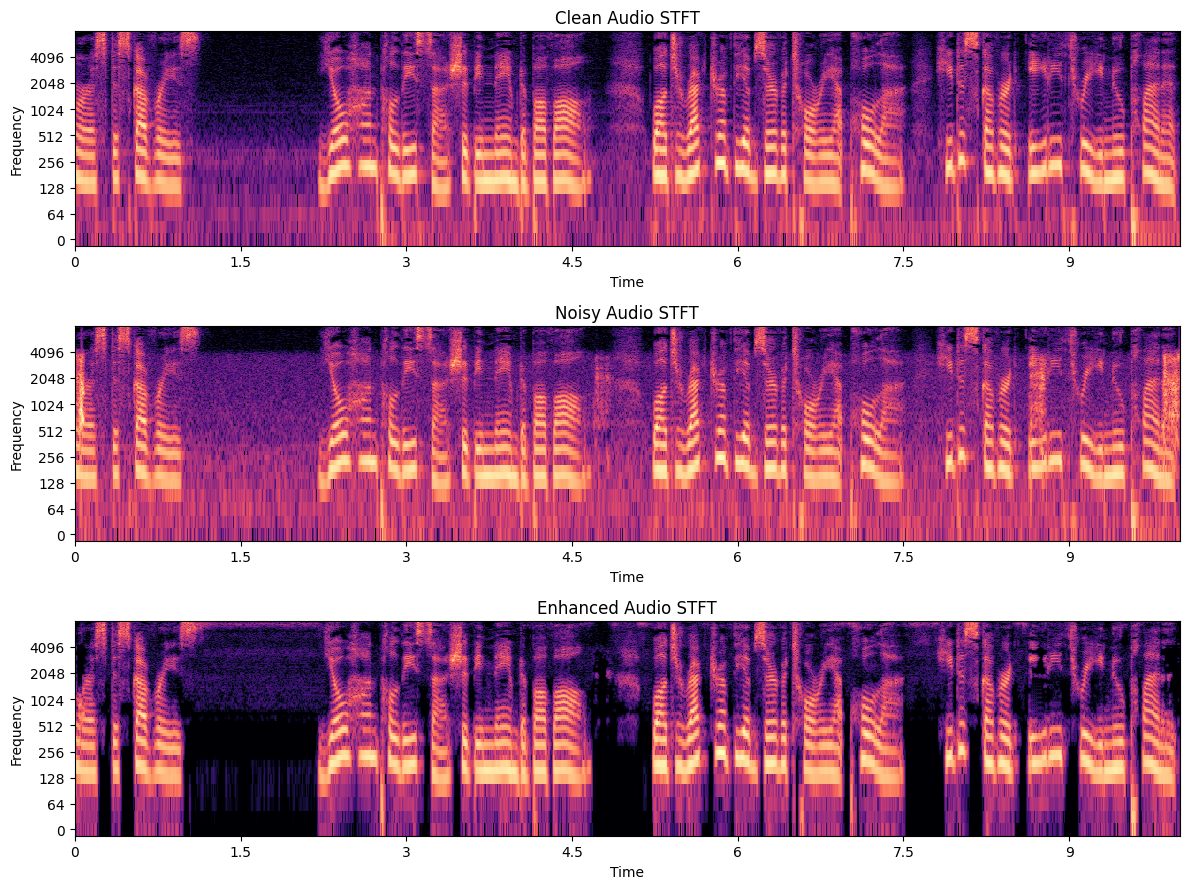

Playing the Clean, Noisy, Enhanced Audio : 
Playing Clean Audio:


Playing Noisy Audio:


Playing Enhanced Audio:


In [ ]:
import torch, os, sys
import soundfile as sf
from pathlib import Path
from glob import glob
from tqdm import tqdm
from collections import OrderedDict
import numpy as np
from librosa import stft, istft, griffinlim, amplitude_to_db
from pystoi import stoi
from pesq import pesq
import speechmetrics
from auraloss.time import SISDRLoss, SNRLoss
from torch import nn
import scipy
# from objective_metrics import lsd
from glob import glob
from IPython.display import Audio
import matplotlib.pyplot as plt
import librosa.display
import re

# Ensure paths are adjusted for Kaggle


    
path = path.replace("\\", "/")
SAVE_DIR = f"{path}/Saved_Models/"
RESULTS_DIR = f"{path}/Result/"
EVAL_FILE_PATH = f"{path}/scpfiles/Test.txt"  # Update this based on dataset structure

class RMSE(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, pred, actual):
        return torch.sqrt(self.mse(pred, actual))
        
def lsd(clean, enhanced):
    clean_spec = np.abs(stft(clean, n_fft=512, hop_length=128))
    enhanced_spec = np.abs(stft(enhanced, n_fft=512, hop_length=128))
    clean_db = amplitude_to_db(clean_spec)
    enhanced_db = amplitude_to_db(enhanced_spec)
    return np.mean(np.sqrt(np.mean((clean_db - enhanced_db) ** 2, axis=1)))

class test_model:
    def __init__(self, modelname, modelfile, evalfile, Loss_function):
        super(test_model, self).__init__()
        self.evalfile = evalfile
        self.modelname = modelname
        self.modelfile = modelfile
        self.Loss_function = Loss_function
        self.rmse = RMSE()
        self.SNRLoss = SNRLoss()

        # Variables to store the last processed audio
        self.last_noisy = None
        self.last_clean = None
        self.last_enhanced = None

    def mapmodule(self, state_dict, keyword='model'):
        model_dict = OrderedDict()
        for key in state_dict.keys():
            if keyword in key:
                new_key = key.replace(keyword + '.', '')
                model_dict[new_key] = state_dict[key]
        return model_dict

    def loadmodel(self):
        
        # Model selection
        if self.modelname == 'CFTNet':
            model = CFTNet()
        elif self.modelname == 'DCCTN':
            model = DCCTN()
        elif self.modelname == 'DATCFTNET':
            model = DATCFTNET()
        elif self.modelname == 'DATCFTNET_DSC':
            model = DATCFTNET_DSC()
        else:
            raise ValueError("Invalid model name provided.")

        # Load checkpoint
        saved_model = torch.load(self.modelfile, map_location='cuda' if torch.cuda.is_available() else 'cpu')
        saved_model['state_dict'] = self.mapmodule(saved_model['state_dict'])
        model.load_state_dict(saved_model['state_dict'])
        model = model.to('cuda' if torch.cuda.is_available() else 'cpu')
        model.eval()
        return model

    def main(self):
        model = self.loadmodel()
        eval_files = open(self.evalfile).readlines()
        eval_files = [i.strip().split(' ') for i in eval_files]

        scores = {
            "STOI_C_N": [], "STOI_C_E": [], "PESQ_C_N": [], "PESQ_C_E": [],
            "LSD_C_N": [], "LSD_C_E": [], "SNRloss_C_N": [], "SNRloss_C_E": [],
            "SISDR_C_N": [], "SISDR_C_E": [], "RMSE_C_N": [], "RMSE_C_E": []
        }
        
        window_length = 5
        metrics = speechmetrics.load(['sisdr'], window_length)

        Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

        for j, audiofile in enumerate(tqdm(eval_files, desc='Decoding Eval Files')):
            # print(audiofile[0])
            noisy_path = f"{audiofile[0]}"
            clean_path = f"{audiofile[1]}"
            
            # noisy = self.norm(sf.read(audiofile[0])[0])
            # clean = self.norm(sf.read(audiofile[1])[0])
            noisy = self.norm(sf.read(noisy_path)[0])
            clean = self.norm(sf.read(clean_path)[0])
            
            clean = self.SPL_cal(clean, 65)
            noisy = self.SPL_cal(noisy, 65)
            with torch.no_grad():
                enh_audio = model(torch.FloatTensor(noisy).unsqueeze(0).to('cuda' if torch.cuda.is_available() else 'cpu')).cpu().numpy()

            enh_audio = self.norm(self.match_dims(noisy, enh_audio))
            enh_audio = self.SPL_cal(enh_audio, 65)
            desname = audiofile[2]
            Path(os.path.dirname(desname)).mkdir(parents=True, exist_ok=True)
            sf.write(desname, enh_audio, 16000)

            # Store for playback
            self.last_noisy = noisy
            self.last_clean = clean
            self.last_enhanced = enh_audio


            # scores_C_N, scores_C_E = metrics(audiofile[0], audiofile[1]), metrics(audiofile[2], audiofile[1])
            scores_C_N, scores_C_E = metrics(noisy_path, clean_path), metrics(clean_path, clean_path)

            scores["SISDR_C_N"].append(scores_C_N['sisdr'][0])
            scores["SISDR_C_E"].append(scores_C_E['sisdr'][0])
            scores["RMSE_C_N"].append(self.rmse(torch.from_numpy(clean), torch.from_numpy(noisy)).item())
            scores["RMSE_C_E"].append(self.rmse(torch.from_numpy(clean), torch.from_numpy(enh_audio)).item())
            scores["PESQ_C_N"].append(pesq(16000, clean, noisy, 'wb'))
            scores["PESQ_C_E"].append(pesq(16000, clean, enh_audio, 'wb'))
            scores["STOI_C_N"].append(stoi(clean, noisy, 16000, extended=False))
            scores["STOI_C_E"].append(stoi(clean, enh_audio, 16000, extended=False))
            scores["LSD_C_N"].append(lsd(clean, noisy))
            scores["LSD_C_E"].append(lsd(clean, enh_audio))
            scores["SNRloss_C_N"].append(self.SNRLoss(torch.from_numpy(clean), torch.from_numpy(noisy)).item())
            scores["SNRloss_C_E"].append(self.SNRLoss(torch.from_numpy(clean), torch.from_numpy(enh_audio)).item())

        # Save results
        np.savez(RESULTS_DIR + 'IEEE_Objective_score_' + self.modelname + '_' + self.Loss_function, **scores)

        # Print summary
        print("\n==== Final Results ====")
        for metric in ["STOI", "PESQ", "SISDR", "LSD", "SNRloss", "RMSE"]:
            print(f"Mean Noisy {metric}: {np.mean(scores[metric + '_C_N']):.3f}")
            print(f"Mean Enhanced {metric}: {np.mean(scores[metric + '_C_E']):.3f}")

    def match_dims(self, rev, enh):
        output = np.zeros_like(rev)
        if len(enh) >= len(rev):
            output = enh[:len(rev)]
        if len(enh) < len(rev):
            output[:len(enh)] = enh
        return output

    def norm(self, x):
        return x / (np.max(np.abs(x)) + 1e-10)

    def SPL_cal(self, x, SPL):
        SPL_before = 20 * np.log10(np.sqrt(np.mean(x ** 2)) / (20 * 1e-6))
        return x * 10 ** ((SPL - SPL_before) / 20)

    def play_audio(self):
        """Play the last processed clean, noisy, and enhanced signals."""
        if self.last_noisy is None:
            print("No audio processed yet.")
            return
        print("Playing the Clean, Noisy, Enhanced Audio : ")
        print("Playing Clean Audio:")
        display(Audio(self.last_clean, rate=16000))
        
        print("Playing Noisy Audio:")
        display(Audio(self.last_noisy, rate=16000))
        
        print("Playing Enhanced Audio:")
        display(Audio(self.last_enhanced, rate=16000))
        
    def plot_stft(self):
        """Plot STFT spectrograms of the clean, noisy, and enhanced signals."""
        print("\nSpectrogram of the Clean, Noisy, Enhanced Signal : ")
        if self.last_noisy is None:
            print("No audio processed yet.")
            return

        def compute_stft(audio):
            return np.abs(librosa.stft(audio, n_fft=512, hop_length=128))

        noisy_stft = compute_stft(self.last_noisy)
        clean_stft = compute_stft(self.last_clean)
        enhanced_stft = compute_stft(self.last_enhanced)

        fig, axes = plt.subplots(3, 1, figsize=(12, 9))

        librosa.display.specshow(librosa.amplitude_to_db(clean_stft, ref=np.max),
                                 sr=16000, hop_length=128, y_axis='log', x_axis='time', ax=axes[0])
        axes[0].set_title("Clean Audio STFT")
        axes[0].set_xlabel("Time")
        axes[0].set_ylabel("Frequency")
        
        librosa.display.specshow(librosa.amplitude_to_db(noisy_stft, ref=np.max),
                                 sr=16000, hop_length=128, y_axis='log', x_axis='time', ax=axes[1])
        axes[1].set_title("Noisy Audio STFT")
        axes[1].set_xlabel("Time")
        axes[1].set_ylabel("Frequency")


        librosa.display.specshow(librosa.amplitude_to_db(enhanced_stft, ref=np.max),
                                 sr=16000, hop_length=128, y_axis='log', x_axis='time', ax=axes[2])
        axes[2].set_title("Enhanced Audio STFT")
        axes[2].set_xlabel("Time")
        axes[2].set_ylabel("Frequency")

        plt.tight_layout()
        plt.show()


if __name__ == '__main__':
    print('Testing the model on Kaggle...')

    modelname = 'DCCTN'
    

    # Fetch all checkpoint files
    model_files = glob(f"{path}{modelname}/*.ckpt")
    if not model_files:
        raise FileNotFoundError(f"No checkpoint files found in {path}{modelname}/")
    
    # Extract validation loss from filename (assuming format: modelname-epoch=XX-val_loss=YY.YY.ckpt)
    def extract_val_loss(filename):
        match = re.search(r"val_loss=([\d]+\.[\d]+)", filename)  # Extract number correctly
        if match:
            return float(match.group(1))  # Convert extracted value to float
        else:
            print(f"Warning: Could not extract val_loss from {filename}. Skipping.")
            return float("inf")  # Return a high value so it's ignored

    # Select the checkpoint with the lowest validation loss
    modelfile = min(model_files, key=extract_val_loss)

    print(f"Model file selected (lowest val_loss): {modelfile}")

    Loss_function = 'SISDR+FreqLoss=-2.93'

    # Ensure test_model is correctly defined
    test = test_model(modelname, modelfile, EVAL_FILE_PATH, Loss_function)
    test.main()
    test.plot_stft()  # Show STFT spectrograms
    test.play_audio()  # Play the last processed signals